# 平时作业3-CNN图像分类
## 1.调用CIFAR-10数据集
从预处理好的数据集中加载训练集和测试集。

In [ ]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# 数据预处理
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
          (0.2023, 0.1994, 0.2010))
])
transforms.RandomErasing(p=0.3)

# 加载训练集
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

# 加载测试集
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# 类别名称
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

## 2.定义网络模型
改动典型CNN网络结构，并进行参数初始化，选取损失函数和优化器，设置超参数。

In [ ]:
import torch
from torch import nn
import torchvision.models as models

net = models.resnet18(num_classes=10)
net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
net.maxpool = nn.Identity()
def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)

loss = nn.CrossEntropyLoss()
lr, num_epochs = 0.05, 40
optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, weight_decay=5e-4)

## 3.训练网络
训练网络参数，并用测试数据集进行分类准确度的量化评估。展示每个epoch的损失函数下降情况、训练数据集的Accuracy和测试数据集的Accuracy。

Epoch 1: loss=1.785, train_acc=0.376, test_acc=0.480
Epoch 2: loss=1.224, train_acc=0.558, test_acc=0.572
Epoch 3: loss=0.946, train_acc=0.662, test_acc=0.687
Epoch 4: loss=0.757, train_acc=0.735, test_acc=0.730
Epoch 5: loss=0.648, train_acc=0.774, test_acc=0.752
Epoch 6: loss=0.568, train_acc=0.801, test_acc=0.766
Epoch 7: loss=0.515, train_acc=0.822, test_acc=0.770
Epoch 8: loss=0.466, train_acc=0.840, test_acc=0.812
Epoch 9: loss=0.432, train_acc=0.851, test_acc=0.821
Epoch 10: loss=0.402, train_acc=0.862, test_acc=0.832
Epoch 11: loss=0.381, train_acc=0.869, test_acc=0.832
Epoch 12: loss=0.364, train_acc=0.875, test_acc=0.843
Epoch 13: loss=0.346, train_acc=0.881, test_acc=0.830
Epoch 14: loss=0.332, train_acc=0.885, test_acc=0.821
Epoch 15: loss=0.322, train_acc=0.890, test_acc=0.832
Epoch 16: loss=0.199, train_acc=0.932, test_acc=0.908
Epoch 17: loss=0.159, train_acc=0.947, test_acc=0.915
Epoch 18: loss=0.141, train_acc=0.954, test_acc=0.912
Epoch 19: loss=0.129, train_acc=0.956

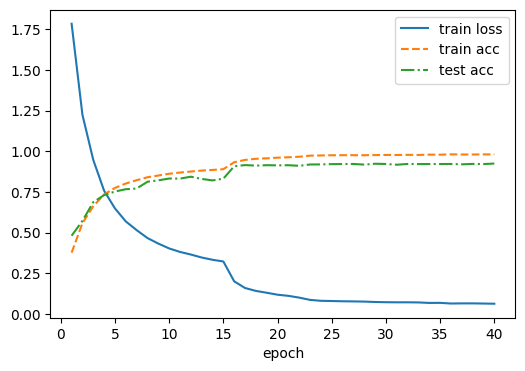

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[15, 22],
    gamma=0.1
)
def evaluate_accuracy(data_iter, net):
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            pred = net(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return correct / total

train_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in range(num_epochs):
    net.train()
    total_loss = 0
    correct = 0
    total = 0

    for X, y in trainloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        y_hat = net(X)
        l = loss(y_hat, y)
        l.backward()
        optimizer.step()

        total_loss += l.item()
        pred = y_hat.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = total_loss / len(trainloader)
    train_acc = correct / total
    test_acc = evaluate_accuracy(testloader, net)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch+1}: loss={train_loss:.3f}, "
          f"train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, num_epochs+1), train_loss_list, label='train loss')
plt.plot(range(1, num_epochs+1), train_acc_list, '--', label='train acc')
plt.plot(range(1, num_epochs+1), test_acc_list, '-.', label='test acc')

plt.xlabel('epoch')
plt.legend()
plt.show()

## 4.预测结果
展示测试集中的10张图像的分类结果。

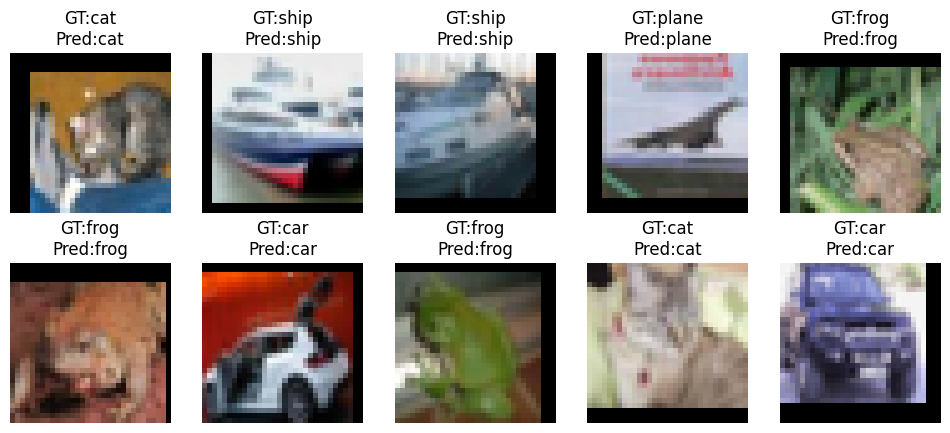

In [ ]:
import numpy as np

def imshow(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1).to(img.device)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1).to(img.device)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

# 取一批测试数据
dataiter = iter(testloader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)
outputs = net(images)
preds = outputs.argmax(dim=1)

# 显示前10张
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    imshow(images[i])
    plt.title(f"GT:{classes[labels[i]]}\nPred:{classes[preds[i]]}")
plt.show()